In [1]:
pip install sqlalchemy pymysql pandas python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import pandas as pd
from dotenv import load_dotenv

In [55]:
load_dotenv()

HOST="127.0.0.1"
USER="root"
PASSWORD="53787"
DATABASE="Predictive_maintainance"

# --- DB Connection ---
# HOST = os.getenv("DB_HOST")
# print(HOST)
# USER = os.getenv("DB_USER")
# PASSWORD = os.getenv("DB_PASSWORD")
# DATABASE = os.getenv("DB_DATABASE")

In [56]:
# --- Read Table ---
query = """
    SELECT trolleyId, type, reason, createdOn
    FROM tbl_trolley_maintenance_50k
"""

In [57]:
from sqlalchemy import create_engine

engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DATABASE}")

df = pd.read_sql(query, engine)  


In [61]:
df.head()

,trolleyId,type,reason,createdOn
0,1,major,Frame Damage,01-01-2025 13:34
1,1,major,Broken & Needs Welding,01-01-2025 16:39
2,1,major,Structural Damage,02-01-2025 03:27
3,1,major,Accident,02-01-2025 11:09
4,1,minor,Brake Adjustment,02-01-2025 13:31


# --- Data Processing ---


In [62]:
# Parse and strip time from createdOn
df["createdOn"] = pd.to_datetime(df["createdOn"], dayfirst=True).dt.normalize()

In [63]:
df['createdOn'].head()

0   2025-01-01
1   2025-01-01
2   2025-01-02
3   2025-01-02
4   2025-01-02
Name: createdOn, dtype: datetime64[us]

In [64]:
df.head()

,trolleyId,type,reason,createdOn
0,1,major,Frame Damage,2025-01-01
1,1,major,Broken & Needs Welding,2025-01-01
2,1,major,Structural Damage,2025-01-02
3,1,major,Accident,2025-01-02
4,1,minor,Brake Adjustment,2025-01-02


In [65]:
# Sort so occurrences are in chronological order
df = df.sort_values(["trolleyId", "reason", "createdOn"]).reset_index(drop=True)

### METHOD 1

In [70]:
df.head()

,trolleyId,type,reason,createdOn
0,1,major,Accident,2025-01-02
1,1,major,Accident,2025-01-05
2,1,major,Accident,2025-01-08
3,1,major,Accident,2025-01-16
4,1,major,Accident,2025-01-17


In [71]:
def avg_days_between_occurrences(dates):
    """Given a sorted list of dates, return the average gap in days between consecutive dates."""
    if len(dates) < 2:
        return None  # Can't compute a gap with only 1 occurrence
    gaps = [(dates[i + 1] - dates[i]).days for i in range(len(dates) - 1)]
    return sum(gaps) / len(gaps)

In [77]:
# Group by trolleyId + reason, collect sorted dates, compute average gap
result = (
    df.groupby(["trolleyId","type", "reason"])["createdOn"]
    .apply(lambda dates: avg_days_between_occurrences(sorted(dates.tolist())))
    .reset_index()
    .rename(columns={"createdOn": "avg_days_between_occurrences"})
)

In [78]:
result

,trolleyId,type,reason,avg_days_between_occurrences
0,1,major,Accident,3.460432
1,1,major,Broken & Needs Welding,3.368794
2,1,major,Frame Damage,3.779528
3,1,major,Motor Failure,3.342657
4,1,major,Structural Damage,3.363636
...,...,...,...,...
325,30,minor,Brake Adjustment,1.401163
326,30,minor,Cleaning & Inspection,1.290323
327,30,minor,Oiling & Greasing,1.358974
328,30,minor,Parts Replacement,1.320442


In [79]:
# Drop rows where avg couldn't be computed (only 1 occurrence)
result = result.dropna(subset=["avg_days_between_occurrences"])
result["avg_days_between_occurrences"] = result["avg_days_between_occurrences"].round().astype(int)

In [75]:
result['avg_days_between_occurrences']

0      3
1      2
2      2
3      3
4      2
      ..
325    2
326    1
327    1
328    2
329    1
Name: avg_days_between_occurrences, Length: 330, dtype: int64

In [80]:
result

,trolleyId,type,reason,avg_days_between_occurrences
0,1,major,Accident,3
1,1,major,Broken & Needs Welding,3
2,1,major,Frame Damage,4
3,1,major,Motor Failure,3
4,1,major,Structural Damage,3
...,...,...,...,...
325,30,minor,Brake Adjustment,1
326,30,minor,Cleaning & Inspection,1
327,30,minor,Oiling & Greasing,1
328,30,minor,Parts Replacement,1


In [90]:
df.head()

,trolleyId,type,reason,createdOn
0,1,major,Accident,2025-01-02
1,1,major,Accident,2025-01-05
2,1,major,Accident,2025-01-08
3,1,major,Accident,2025-01-16
4,1,major,Accident,2025-01-17


In [87]:
result.head()

,trolleyId,type,reason,avg_days_between_occurrences
0,1,major,Accident,3
1,1,major,Broken & Needs Welding,3
2,1,major,Frame Damage,4
3,1,major,Motor Failure,3
4,1,major,Structural Damage,3


### mETHOD 2

In [91]:
df.head()

,trolleyId,type,reason,createdOn
0,1,major,Accident,2025-01-02
1,1,major,Accident,2025-01-05
2,1,major,Accident,2025-01-08
3,1,major,Accident,2025-01-16
4,1,major,Accident,2025-01-17


In [92]:
# get next issue date within each group
df["nextIssueOn"] = df.groupby(["trolleyId", "reason"])["createdOn"].shift(-1)

In [95]:
df.head()

,trolleyId,type,reason,createdOn,nextIssueOn
0,1,major,Accident,2025-01-02,2025-01-05
1,1,major,Accident,2025-01-05,2025-01-08
2,1,major,Accident,2025-01-08,2025-01-16
3,1,major,Accident,2025-01-16,2025-01-17
4,1,major,Accident,2025-01-17,2025-01-17


In [100]:
# calculate difference in days
df["difference"] = (df["nextIssueOn"] - df["createdOn"]).dt.days

In [101]:
df.head()

,trolleyId,type,reason,createdOn,nextIssueOn,difference
0,1,major,Accident,2025-01-02,2025-01-05,3.0
1,1,major,Accident,2025-01-05,2025-01-08,3.0
2,1,major,Accident,2025-01-08,2025-01-16,8.0
3,1,major,Accident,2025-01-16,2025-01-17,1.0
4,1,major,Accident,2025-01-17,2025-01-17,0.0


In [102]:
df["difference"] = df["difference"].fillna(0).astype(int)

In [103]:
df.head()

,trolleyId,type,reason,createdOn,nextIssueOn,difference
0,1,major,Accident,2025-01-02,2025-01-05,3
1,1,major,Accident,2025-01-05,2025-01-08,3
2,1,major,Accident,2025-01-08,2025-01-16,8
3,1,major,Accident,2025-01-16,2025-01-17,1
4,1,major,Accident,2025-01-17,2025-01-17,0


In [111]:
df.head()

,trolleyId,type,reason,createdOn,nextIssueOn,difference
0,1,major,Accident,2025-01-02,2025-01-05,3
1,1,major,Accident,2025-01-05,2025-01-08,3
2,1,major,Accident,2025-01-08,2025-01-16,8
3,1,major,Accident,2025-01-16,2025-01-17,1
4,1,major,Accident,2025-01-17,2025-01-17,0


#EDA

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49992 entries, 0 to 49991
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   trolleyId    49992 non-null  int64         
 1   type         49992 non-null  str           
 2   reason       49992 non-null  str           
 3   createdOn    49992 non-null  datetime64[us]
 4   nextIssueOn  49662 non-null  datetime64[us]
 5   difference   49992 non-null  int64         
dtypes: datetime64[us](2), int64(2), str(2)
memory usage: 2.3 MB


In [113]:
df.isnull().sum()

trolleyId        0
type             0
reason           0
createdOn        0
nextIssueOn    330
difference       0
dtype: int64

In [114]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [115]:
import seaborn as sns

<Axes: ylabel='type'>

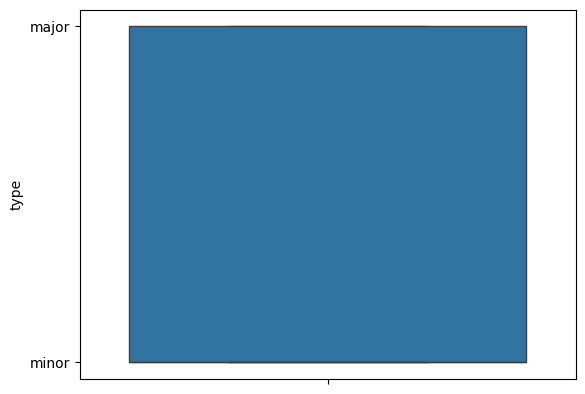

In [116]:
sns.boxplot(df['type'])

<Axes: ylabel='reason'>

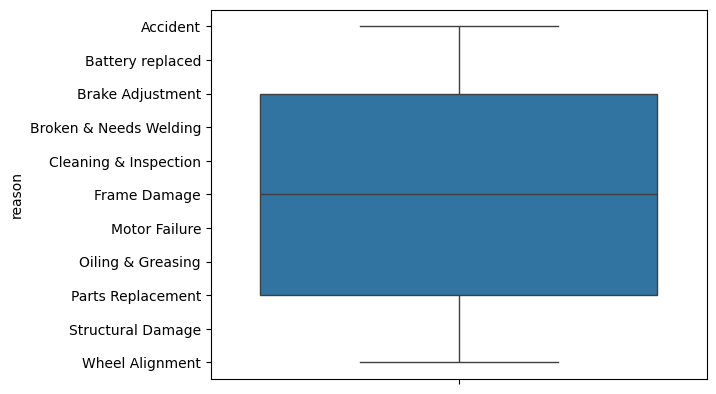

In [117]:
sns.boxplot(df['reason'])

# 1.Feature Engineering 

In [118]:
import pandas as pd

df["createdOn"] = pd.to_datetime(df["createdOn"])

# extract useful time features
df["day"] = df["createdOn"].dt.day
df["month"] = df["createdOn"].dt.month
df["day_of_week"] = df["createdOn"].dt.dayofweek

# drop unwanted columns
df = df.drop(columns=["trolleyId", "createdOn", "nextIssueOn"])

In [119]:
df.head()

,type,reason,difference,day,month,day_of_week
0,major,Accident,3,2,1,3
1,major,Accident,3,5,1,6
2,major,Accident,8,8,1,2
3,major,Accident,1,16,1,3
4,major,Accident,0,17,1,4


# 2 ENCODING

In [120]:
from sklearn.preprocessing import LabelEncoder
import joblib

le_type = LabelEncoder()
le_reason = LabelEncoder()

df["type"] = le_type.fit_transform(df["type"])
df["reason"] = le_reason.fit_transform(df["reason"])

# save encoders
joblib.dump(le_type, r"pkl\type_encoder.pkl")
joblib.dump(le_reason, r"pkl\reason_encoder.pkl")

['pkl\\reason_encoder.pkl']

In [123]:
df.head()

,type,reason,difference,day,month,day_of_week
0,0,0,3,2,1,3
1,0,0,3,5,1,6
2,0,0,8,8,1,2
3,0,0,1,16,1,3
4,0,0,0,17,1,4


In [128]:
df['type'].value_counts()

type
1    32392
0    17600
Name: count, dtype: int64

In [129]:
df['reason'].value_counts()

reason
10    5480
7     5479
4     5438
8     5410
1     5324
2     5261
6     3634
3     3551
5     3513
9     3466
0     3436
Name: count, dtype: int64

# 3 train test split

In [121]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["difference"])
y = df["difference"]



In [122]:
X.head()

,type,reason,day,month,day_of_week
0,0,0,2,1,3
1,0,0,5,1,6
2,0,0,8,1,2
3,0,0,16,1,3
4,0,0,17,1,4


In [130]:
y.head()

0    3
1    3
2    8
3    1
4    0
Name: difference, dtype: int64

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train model

(i) RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

RFR_model = RandomForestRegressor(n_estimators=100)
RFR_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [135]:
joblib.dump(RFR_model,r"pkl\randomforestreg_for_predictive_maintainance.pkl")

['pkl\\randomforestreg_for_predictive_maintainance.pkl']

(ii)DecisionTreeRegressor

In [138]:
from sklearn.tree import DecisionTreeRegressor
# 1. Initialize the model
# Using max_depth=3 helps prevent overfitting (making the tree too complex)
DTR_model = DecisionTreeRegressor(max_depth=3, random_state=42)

# 2. Fit the model to training data
DTR_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [139]:
# 3. Make predictions
DTR_pred = DTR_model.predict(X_test)


In [141]:
joblib.dump(DTR_model,r'pkl\decisiontreeregress_for_predictive')

['pkl\\decisiontreeregress_for_predictive']

# Evaluate the model

(i) evaluate randomforest

In [136]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [137]:
y_RFR_pred = RFR_model.predict(X_test)

# metrics
mae = mean_absolute_error(y_test, y_RFR_pred)
mse = mean_squared_error(y_test, y_RFR_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_RFR_pred)


print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.854316458460447
MSE: 19.046724325947064
RMSE: 4.364255300271407
R2 Score: -0.1354459321641046


(ii)decisionforest

In [ ]:
DTR_pred = DTR_model.predict(X_test)

# metrics
mae = mean_absolute_error(y_test, DTR_pred)
mse = mean_squared_error(y_test, DTR_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, DTR_pred)


print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

InvalidParameterError: The 'y_pred' parameter of mean_absolute_error must be an array-like. Got DecisionTreeRegressor(max_depth=3, random_state=42) instead.